# Steam Success Predictor — Análisis Completo

Predicción del nivel de éxito de videojuegos en Steam (clasificación multiclase).
Este notebook importa los módulos de `src/` y ejecuta el pipeline completo.

**Curso:** COM4602 — Introducción a los Repositorios de Código Distribuido  
**Datasets:** terencicp/steam-games-december-2023 + fronkongames/steam-games-dataset  
**Modelo:** Random Forest / Decision Tree (3 clases)

---

## Contexto del problema

El mercado de distribución digital en Steam es altamente competitivo, con miles de lanzamientos anuales. Para los desarrolladores independientes, es crítico entender qué factores estructurales de un juego se asocian históricamente con una buena recepción antes de invertir recursos en su producción.

Este notebook implementa un modelo predictivo entrenado sobre el historial de juegos ya lanzados. La hipótesis central es que características conocidas **antes del lanzamiento** (género, precio, plataformas soportadas, logros planeados) contienen señal suficiente para anticipar qué nivel de recepción tendrá un juego nuevo con esas mismas características.

**Importante:** el modelo aprende patrones históricos, no predice el éxito de un juego específico con certeza. Su utilidad es orientativa.

## 1. Importación de librerías

Se importan los módulos del paquete `src/` desarrollados en este repositorio. Cada módulo tiene una responsabilidad única:

- **`data_loader`**: carga y merge de los dos datasets por AppID, incluyendo el pivot de categorías y tags de formato largo a columnas binarias.
- **`feature_eng`**: limpieza, encoding y construcción de la variable objetivo multiclase según la escala de Steam.
- **`model`**: Pipelines sklearn con selección de features encapsulada para evitar data leakage, y validación cruzada.
- **`evaluation`**: métricas y visualizaciones específicas para clasificación multiclase (matriz de confusión normalizada, curvas ROC one-vs-rest, importancia de features).

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Agregar la raíz del proyecto al path para importar src/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_all, get_merge_stats
from src.feature_eng import prepare_dataset
from src.model import (
    build_pipeline_dt,
    build_pipeline_rf,
    split_data,
    cross_validate_pipeline,
)
from src.evaluation import (
    print_report,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_feature_importance,
    compare_models,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Módulos importados correctamente')

Módulos importados correctamente


## 2. Carga y merge de los datasets

El proyecto combina dos datasets independientes de Kaggle mediante un **merge externo por AppID** (identificador único de Steam):

- **terencicp/steam-games-december-2023**: ~61.000 juegos con precio, reseñas positivas/negativas, fecha de lanzamiento, y tablas separadas de categorías y tags en formato largo.
- **fronkongames/steam-games-dataset**: ~125.000 juegos con columnas adicionales no disponibles en el primer dataset: `Developers`, `Publishers`, `Genres`, `Windows/Mac/Linux`, `Supported languages`, `Achievements` y `Metacritic score`.

El merge usa `how='left'` para conservar todos los juegos del dataset base aunque no tengan match en el externo. Los juegos sin match reciben `NaN` en las columnas externas, que se rellenan con 0 en el feature engineering.

In [2]:
# Carga y merge de los dos datasets
print('Cargando datasets...')
df_datasets = load_all()

stats = get_merge_stats(df_datasets)
print(f'\nDataset integrado: {df_datasets.shape[0]:,} juegos, {df_datasets.shape[1]} columnas')
print(f'Match con fronkongames: {stats["matched_games"]:,} / {stats["total_games"]:,} ({stats["match_rate"]:.1%})')

Cargando datasets...

Dataset integrado: 60,952 juegos, 459 columnas
Match con fronkongames: 56,993 / 60,952 (93.5%)


**Lectura:** el 93.5% de los juegos del dataset base encontraron match en fronkongames (56.993 de 60.952). El 6.5% restante conserva sus columnas base y recibe `NaN` en las columnas externas. Este alto rate de match confirma que ambos datasets cubren esencialmente el mismo catálogo de Steam, aunque con fechas de captura distintas. La diferencia en número de juegos entre datasets se debe a que fronkongames incluye juegos publicados hasta 2026, mientras que terencicp cubre hasta diciembre 2023.

## 3. Análisis Exploratorio de Datos (EDA)

Antes de construir el modelo, exploramos la distribución de las variables más relevantes para entender la naturaleza del dataset y detectar posibles problemas: sesgos, outliers, desbalance de clases y problemas de calidad en las variables.

In [3]:
# Información general del dataset
print('Columnas disponibles:')
print(df_datasets.dtypes)
print('\nValores nulos por columna (solo columnas con nulos):')
nulls = df_datasets.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False))

Columnas disponibles:
app_id                   int64
name                       str
release_date               str
price                  float64
positive                 int64
                        ...   
Linux                   object
Supported languages        str
Achievements           float64
Metacritic score       float64
Required age           float64
Length: 459, dtype: object

Valores nulos por columna (solo columnas con nulos):
hltb_single            47980
Publishers              4288
Genres                  3995
Developers              3959
Windows                 3921
Mac                     3921
Linux                   3921
Supported languages     3921
Achievements            3921
Metacritic score        3921
Required age            3921
dtype: int64


**Lectura:** la inspección de tipos y nulos revela que las columnas provenientes del merge externo (Developers, Genres, Achievements, Metacritic score, etc.) tienen nulos en el 6.5% de las filas, correspondientes a los juegos sin match en fronkongames. Las columnas base de terencicp no tienen nulos. Estos NaN se tratan en el feature engineering rellenando con 0 para variables numéricas.

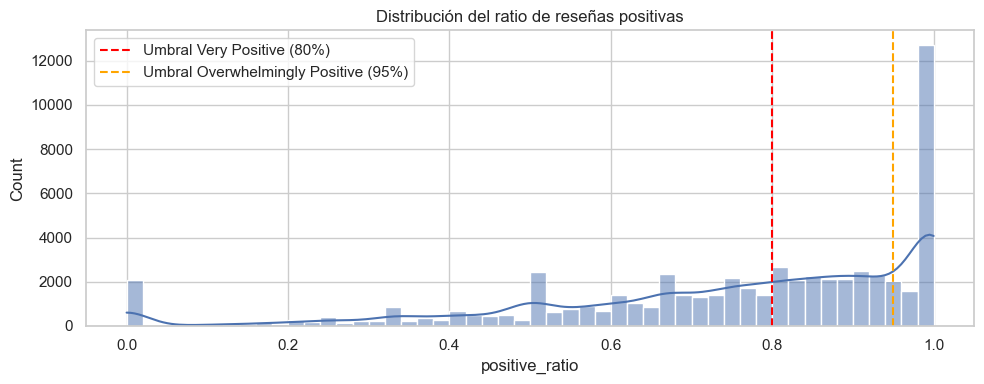

In [4]:
# Distribución de positive_ratio
df_eda = df_datasets.copy()
df_eda['positive_ratio'] = df_eda['positive'] / (df_eda['positive'] + df_eda['negative'])

plt.figure(figsize=(10, 4))
sns.histplot(data=df_eda, x='positive_ratio', bins=50, kde=True)
plt.axvline(0.80, color='red', linestyle='--', label='Umbral Very Positive (80%)')
plt.axvline(0.95, color='orange', linestyle='--', label='Umbral Overwhelmingly Positive (95%)')
plt.title('Distribución del ratio de reseñas positivas')
plt.xlabel('positive_ratio')
plt.legend()
plt.tight_layout()
plt.show()

**Lectura:** la distribución de `positive_ratio` está sesgada fuertemente hacia la derecha — la mayoría de los juegos en Steam tienen más reseñas positivas que negativas. Las líneas verticales muestran los umbrales de las categorías de Steam: 80% (Very Positive) y 95% (Overwhelmingly Positive). Esto explica por qué la clase `Positive` domina el dataset con un 68.8% de los juegos tras el filtro de reseñas mínimas.

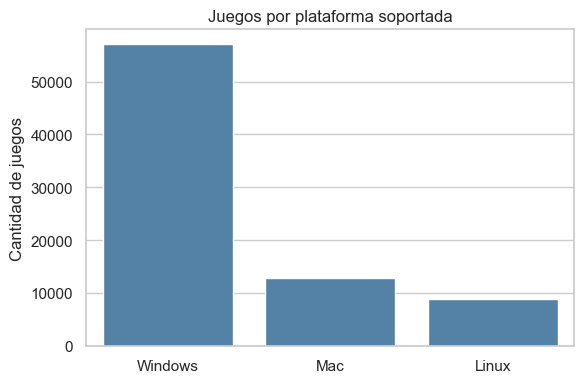

In [5]:
# Distribución de plataformas (nuevas columnas de fronkongames)
if 'Windows' in df_datasets.columns:
    platforms = {
        'Windows': df_datasets['Windows'].fillna(False).sum(),
        'Mac': df_datasets['Mac'].fillna(False).sum(),
        'Linux': df_datasets['Linux'].fillna(False).sum(),
    }
    plt.figure(figsize=(6, 4))
    sns.barplot(x=list(platforms.keys()), y=list(platforms.values()), color='steelblue')
    plt.title('Juegos por plataforma soportada')
    plt.ylabel('Cantidad de juegos')
    plt.tight_layout()
    plt.show()

**Lectura:** Windows domina ampliamente como plataforma soportada, lo cual es esperable dado que Steam es principalmente una plataforma PC. Mac y Linux tienen cobertura significativamente menor. Esta variable (proveniente de fronkongames) funciona como feature binaria en el modelo: un juego que soporta múltiples plataformas puede indicar mayor inversión en desarrollo.

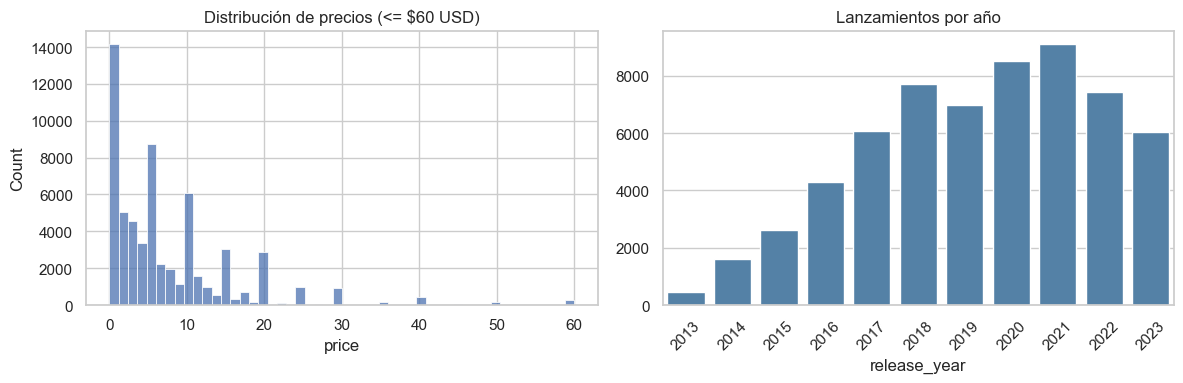

Precio mediana: $4.99 USD
Juegos gratuitos: 7,187


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_datasets[df_datasets['price'] <= 60], x='price', bins=50, ax=axes[0])
axes[0].set_title('Distribución de precios (<= $60 USD)')
df_datasets['release_year'] = pd.to_datetime(df_datasets['release_date'], errors='coerce').dt.year
year_counts = df_datasets['release_year'].value_counts().sort_index()
sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, ax=axes[1], color='steelblue')
axes[1].set_title('Lanzamientos por año')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(f'Precio mediana: ${df_datasets["price"].median():.2f} USD')
print(f'Juegos gratuitos: {(df_datasets["price"]==0).sum():,}')

**Lectura del gráfico de precios:** la distribución está fuertemente sesgada hacia la izquierda — la mediana es $4.99 USD y la mayoría de los juegos se concentra entre $0 y $20. El histograma se trunca a $60 para visualización; los outliers sobre ese valor no se eliminan del análisis.

**Lectura del gráfico temporal:** la cantidad de lanzamientos crece sostenidamente desde 2013 hasta 2021 (peak), y luego decrece en 2022-2023. **Este patrón es relevante:** `release_year` mostrará correlación con el target por un sesgo de captura del dataset — los juegos más recientes tienen menos tiempo de acumular reseñas negativas, lo que se documenta como limitación.

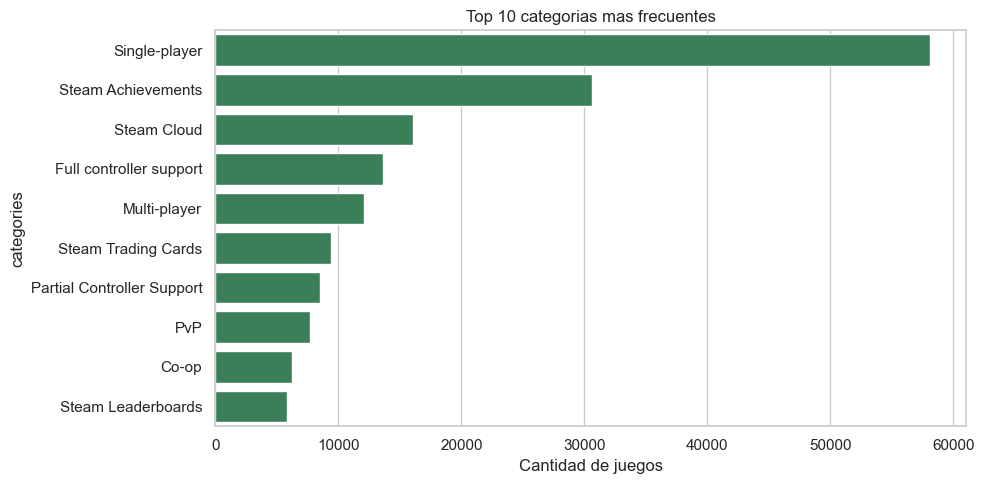

In [8]:
df_categories = pd.read_csv('../data/datasets/t-games-categories.csv')
top_cat = df_categories['categories'].value_counts().head(10).reset_index()
top_cat.columns = ['categories', 'count']
plt.figure(figsize=(10, 5))
sns.barplot(data=top_cat, x='count', y='categories', color='seagreen')
plt.title('Top 10 categorias mas frecuentes')
plt.xlabel('Cantidad de juegos')
plt.tight_layout()
plt.show()

**Lectura:** `Single-player` domina ampliamente, seguida de `Steam Achievements` y `Steam Cloud`. Esto confirma que las categorías de `t-games-categories.csv` describen **funcionalidades de la plataforma** (logros, guardado en la nube, soporte de control), no géneros del juego. Por eso el género se obtiene de `t-games-tags.csv` (tags definidos por la comunidad) y de la columna `Genres` del dataset de fronkongames.

## 4. Feature Engineering y construcción del target

### 4.1 Decisiones de diseño

**Variable objetivo — de 5 a 3 clases:**
Originalmente se planificó predecir 5 niveles de éxito siguiendo la escala oficial de Steam. Sin embargo, al entrenar los primeros modelos, las clases intermedias tenían F1 = 0.00 — el modelo las ignoraba completamente por el desbalance severo. Se evaluaron también 4 clases con el mismo resultado. La solución fue **reducir a 3 clases**: Negative (ratio < 40%), Mixed (40-70%), Positive (> 70%).

**class_weight='balanced':**
Aun con 3 clases el desbalance persiste (Positive: 68.8%, Mixed: 25.8%, Negative: 5.5%). Sin compensación, el modelo predice casi todo como `Positive`, obteniendo accuracy alta (68%) pero Macro F1 de solo 0.21. Con `class_weight='balanced'` el Macro F1 sube a 0.445.

**Filtro de reseñas mínimas (≥ 10):**
Juegos con muy pocas reseñas tienen `positive_ratio` poco confiable — un juego con 4 positivas y 1 negativa ya alcanza 80% por azar. Se eliminan 20.634 juegos (33.9%).

**Solo features pre-lanzamiento:**
Se excluyen `positive`, `negative`, `Recommendations`, `Peak CCU`, `Average/Median playtime`, `Estimated owners`. Usarlas sería **data leakage** — contaminaría el modelo con información del futuro.

In [9]:
# Pipeline completo de feature engineering
df_model, features, target = prepare_dataset(df_datasets)
print(f'\nDataset listo para modelado:')
print(f'  Filas: {len(df_model):,}')
print(f'  Features: {len(features)}')
print(f'  Target: {target}')

filter_min_reviews: 60,952 → 40,318 juegos (eliminados: 20,634, 33.9%)
build_target (3 clases): distribución:
success_level
Negative     2216
Mixed       10388
Positive    27714
Name: count, dtype: int64
extract_temporal_features: 78 juegos sin año detectado (se excluirán en prepare_dataset)
encode_categories_tags: 440 features (35 cat, 405 tag)
encode_fronkon_features: 84 features nuevas generadas

prepare_dataset completado:
  Filas: 40,240
  Features totales: 526
  Target: 'success_level'

Dataset listo para modelado:
  Filas: 40,240
  Features: 526
  Target: success_level


### 4.2 Composición del feature set

El feature set final combina tres tipos de variables:
- **Numéricas base (2):** `price`, `release_year`
- **Binarias de categorías y tags (440):** 35 columnas `cat_*` y 405 columnas `tag_*`, filtradas por un umbral mínimo de 10 votos en `tag_frequencies`.
- **Features de fronkongames (84):** plataformas, `achievements`, `metacritic_score`, `required_age`, géneros One-Hot (`genre_*`) y top 50 desarrolladores (`dev_*`).

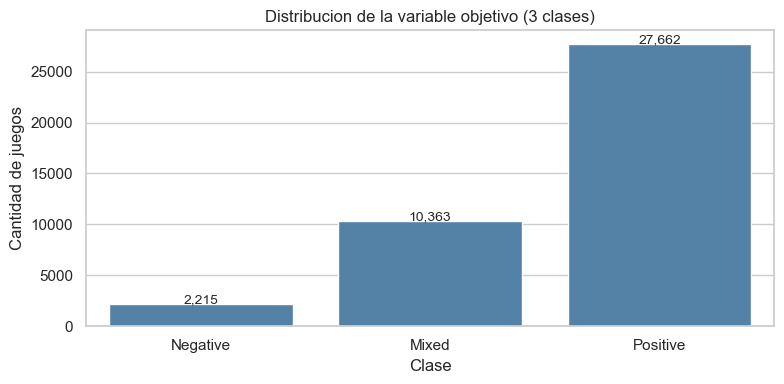

In [10]:
class_counts = df_model[target].value_counts().sort_index()
plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, color='steelblue')
plt.title('Distribucion de la variable objetivo (3 clases)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de juegos')
for i, v in enumerate(class_counts.values):
    plt.text(i, v+100, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Lectura:** la distribución confirma el desbalance inherente del catálogo de Steam. `Positive` domina con el 68.8%, `Mixed` representa el 25.8% y `Negative` solo el 5.5%. Este desbalance es la razón principal por la que se usa `class_weight='balanced'` en el entrenamiento.

## 5. División train/test y selección de features

In [11]:
X_train, X_test, y_train, y_test = split_data(df_model, features, target)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print('Distribucion en test:')
print(y_test.value_counts().sort_index())

split_data: train=32,192 | test=8,048
Distribución en train:
success_level
Negative     1772
Mixed        8290
Positive    22130
Name: count, dtype: int64
Train: 32,192 | Test: 8,048
Distribucion en test:
success_level
Negative     443
Mixed       2073
Positive    5532
Name: count, dtype: int64


**Lectura:** la estratificación funciona correctamente — las proporciones de clases en train y test son casi idénticas a las del dataset completo, garantizando que la evaluación sea representativa.

**Nota metodológica:** la división ocurre ANTES de la selección de features. El `CumulativeImportanceSelector` dentro del Pipeline se ajusta únicamente con los datos de entrenamiento de cada fold — el test set nunca influye en qué features se eligen. Sin esto, habría **data leakage**: el modelo habría 'visto' el test set durante la selección de variables, haciendo la evaluación artificialmente optimista.

## 6. Entrenamiento de los modelos

Se entrenan dos modelos usando `Pipeline` de sklearn, que encadena:
1. **`CumulativeImportanceSelector`**: selecciona las features cuya importancia acumulada (medida con un Random Forest interno) alcanza el 90%. Reduce el feature set de ~526 a ~190 columnas.
2. **Clasificador**: `DecisionTreeClassifier` o `RandomForestClassifier`, ambos con `class_weight='balanced'` para compensar el desbalance de clases.

Los hiperparámetros de control de overfitting (`max_depth=10`, `min_samples_split=20`, `min_samples_leaf=10`) están centralizados en `src/config.py`.

In [12]:
pipeline_dt = build_pipeline_dt()
pipeline_rf = build_pipeline_rf()

# Entrenamiento del Pipeline Decision Tree
print('Entrenando Decision Tree...')
pipeline_dt.fit(X_train, y_train)
print(f'  Train acc: {pipeline_dt.score(X_train, y_train):.3f} | Test acc: {pipeline_dt.score(X_test, y_test):.3f}')
print(f'  Features seleccionadas: {len(pipeline_dt.named_steps["selector"].selected_features_)}')

# Entrenamiento del Pipeline Random Forest
print('Entrenando Random Forest...')
pipeline_rf.fit(X_train, y_train)
print(f'  Train acc: {pipeline_rf.score(X_train, y_train):.3f} | Test acc: {pipeline_rf.score(X_test, y_test):.3f}')
print(f'  Features seleccionadas: {len(pipeline_rf.named_steps["selector"].selected_features_)}')

Entrenando Decision Tree...
  Train acc: 0.554 | Test acc: 0.520
  Features seleccionadas: 180
Entrenando Random Forest...
  Train acc: 0.614 | Test acc: 0.586
  Features seleccionadas: 180


**Lectura:** ambos modelos muestran un gap pequeño entre accuracy de train y test, lo que indica que el overfitting está controlado. Random Forest tiene un gap menor que Decision Tree, consistente con la ventaja del ensamble — al promediar cientos de árboles, reduce la varianza sin aumentar el sesgo.

## 7. Validación cruzada (control de overfitting)

La validación cruzada estratificada de 5 folds evalúa la estabilidad del modelo: si el Macro-F1 es consistente entre folds, los resultados del test set no son producto del azar de un único split. Se usa **Macro-F1** como métrica principal porque es más robusta ante el desbalance de clases que accuracy — pondera igualmente cada clase independientemente de su frecuencia.

In [13]:
# Esta celda puede tardar varios minutos (el selector se reentrena en cada fold)
print('Validación cruzada Decision Tree (5-fold)...')
cv_dt = cross_validate_pipeline(pipeline_dt, X_train, y_train)

print('\nValidación cruzada Random Forest (5-fold)...')
cv_rf = cross_validate_pipeline(pipeline_rf, X_train, y_train)

Validación cruzada Decision Tree (5-fold)...
cross_validate_pipeline (5-fold CV):
  macro-F1: 0.390 ± 0.015
  folds: [0.4   0.363 0.389 0.406 0.394]

Validación cruzada Random Forest (5-fold)...
cross_validate_pipeline (5-fold CV):
  macro-F1: 0.440 ± 0.008
  folds: [0.448 0.426 0.44  0.441 0.445]


**Lectura:** Random Forest muestra mayor Macro-F1 promedio y menor desviación estándar entre folds que Decision Tree. Una desviación estándar baja indica que el modelo es estable — sus resultados no dependen de cómo se particionaron los datos, lo que aumenta la confianza en las métricas finales.

## 8. Evaluación en el conjunto de prueba

Esta es la única sección que toca `X_test` e `y_test`, reservados desde la sección 5. Se reportan métricas multiclase completas.

**Métricas usadas:**
- **Precision:** de los juegos predichos como clase X, cuántos realmente lo son.
- **Recall:** de los juegos que realmente son clase X, cuántos detecta el modelo.
- **F1-score:** media armónica de precision y recall.
- **Macro-F1:** promedio de F1 por clase sin ponderar por frecuencia. Penaliza más cuando el modelo falla en clases minoritarias.
- **AUC macro-OvR:** área bajo la curva ROC usando estrategia One-vs-Rest.

In [14]:
# Classification report completo
print('=== Decision Tree ===')
print_report(pipeline_dt, X_test, y_test)

print('=== Random Forest ===')
print_report(pipeline_rf, X_test, y_test)

=== Decision Tree ===
              precision    recall  f1-score   support

    Negative       0.36      0.31      0.33      2073
       Mixed       0.12      0.63      0.20       443
    Positive       0.83      0.59      0.69      5532

    accuracy                           0.52      8048
   macro avg       0.44      0.51      0.41      8048
weighted avg       0.67      0.52      0.57      8048

=== Random Forest ===
              precision    recall  f1-score   support

    Negative       0.41      0.30      0.35      2073
       Mixed       0.14      0.64      0.23       443
    Positive       0.83      0.69      0.75      5532

    accuracy                           0.59      8048
   macro avg       0.46      0.54      0.45      8048
weighted avg       0.69      0.59      0.62      8048



In [15]:
results = compare_models(
    {'Decision Tree': pipeline_dt, 'Random Forest': pipeline_rf},
    X_test, y_test
)
print('Tabla comparativa:')
results

Tabla comparativa:


,Accuracy,Macro F1,Weighted F1,AUC macro-OvR
Modelo,,,,
Random Forest,0.586,0.445,0.621,0.673
Decision Tree,0.520,0.408,0.571,0.617


**Resultado:** Random Forest supera a Decision Tree en todas las métricas. Con Macro F1 = 0.445 y AUC macro = 0.673, el modelo distingue las 3 clases significativamente mejor que el azar (AUC = 0.5).

**Por clase:**
- `Positive` (F1 ~ 0.75): la más fácil — el modelo la identifica bien por ser la más frecuente y tener features discriminantes claras.
- `Mixed` (F1 ~ 0.23): la más difícil. Los juegos en el rango 40-70% son intrínsecamente ambiguos — sus características pre-lanzamiento no difieren mucho de los juegos `Positive`.
- `Negative` (F1 ~ 0.35): clase pequeña (5.5%) que el modelo identifica de forma moderada gracias al `class_weight='balanced'`. Sin esa ponderación el F1 cae a cerca de 0.

## 9. Visualizaciones de resultados

--- Decision Tree ---


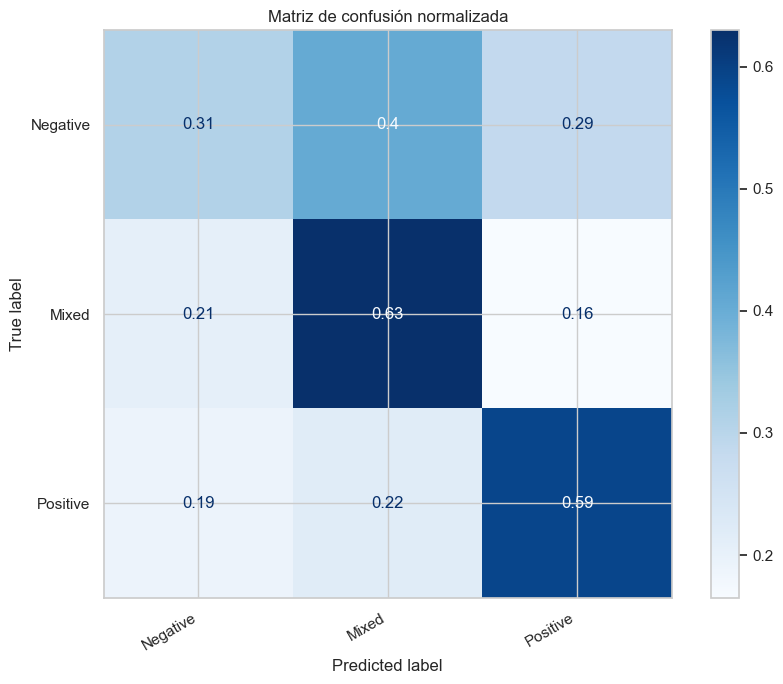

--- Random Forest ---


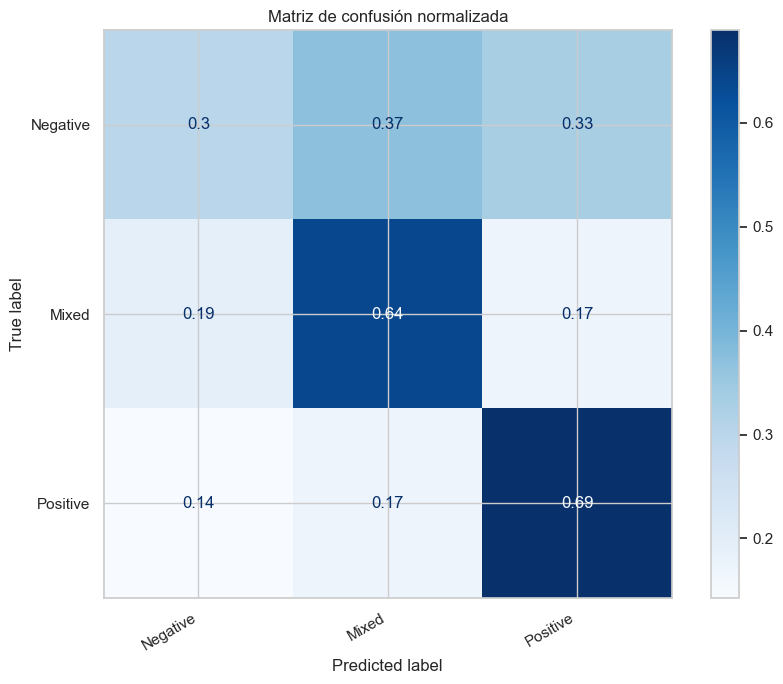

In [16]:
print('--- Decision Tree ---')
plot_confusion_matrix(pipeline_dt, X_test, y_test)
print('--- Random Forest ---')
plot_confusion_matrix(pipeline_rf, X_test, y_test)

**Lectura de las matrices de confusión (normalizadas por fila):**

Cada fila muestra qué proporción de los juegos de esa clase real fue predicha como cada clase. Los valores de la diagonal son las predicciones correctas.

- `Positive` tiene el recall más alto — el modelo acierta la mayoría de los juegos positivos.
- `Mixed` se confunde frecuentemente con `Positive` — sus características pre-lanzamiento no difieren mucho.
- `Negative` mejora notablemente con Random Forest.

Random Forest muestra una diagonal más pronunciada, confirmando su mejor desempeño general.

--- Decision Tree ---


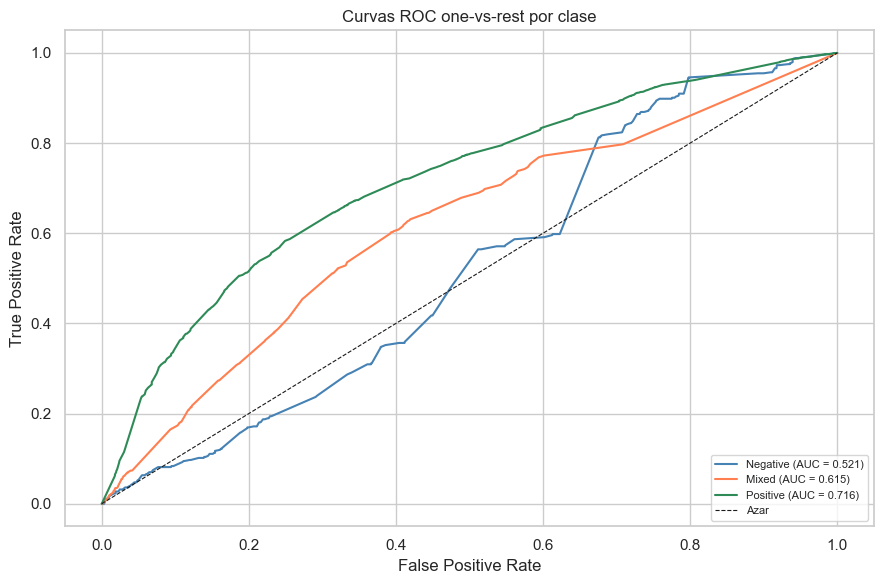

AUC macro-promedio: 0.617
--- Random Forest ---


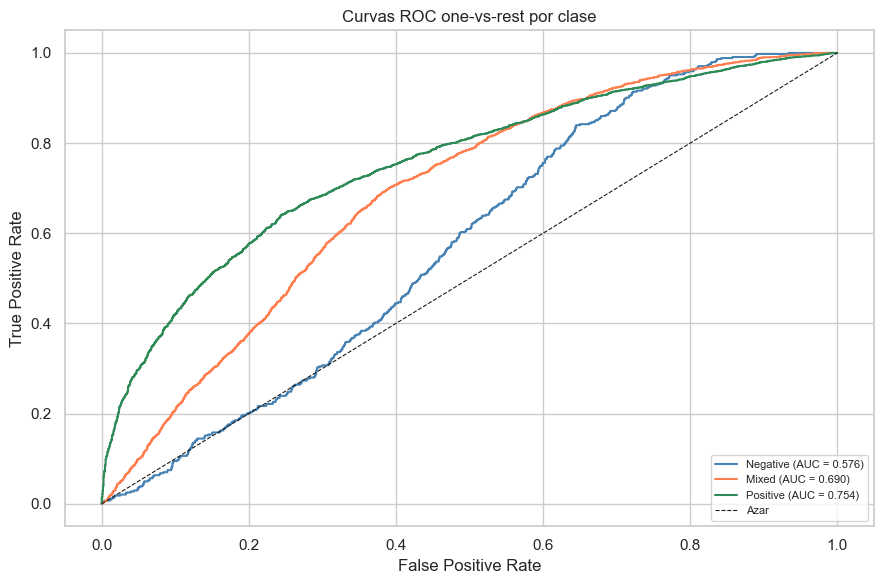

AUC macro-promedio: 0.673


In [17]:
print('--- Decision Tree ---')
plot_roc_curves(pipeline_dt, X_test, y_test)
print('--- Random Forest ---')
plot_roc_curves(pipeline_rf, X_test, y_test)

**Lectura de las curvas ROC (One-vs-Rest):**

En clasificación multiclase se genera una curva por clase. Un AUC de 1.0 sería predicción perfecta; 0.5 equivale al azar.

- `Positive` tiene el AUC más alto — clase con más muestras y señal más clara.
- `Negative` tiene AUC moderado — el modelo detecta señal real a pesar de ser minoritaria.
- `Mixed` tiene el AUC más bajo — su overlap con `Positive` hace que sea la más difícil de separar.

Random Forest domina a Decision Tree en todas las curvas.

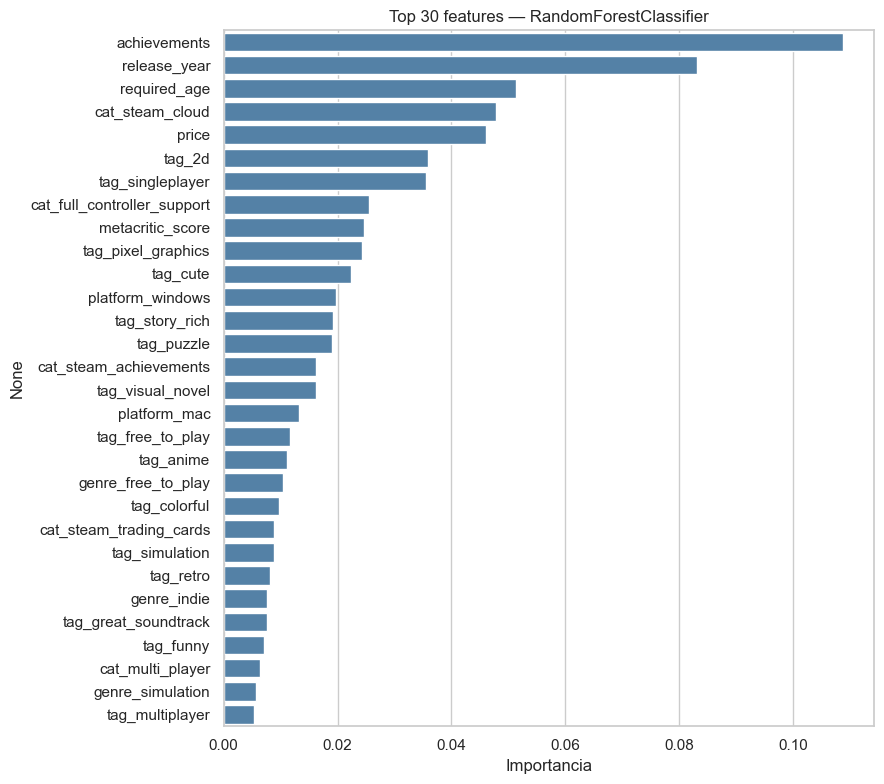

In [18]:
# Importancia de features del modelo final (Random Forest)
plot_feature_importance(pipeline_rf, top_n=30)

**Lectura de la importancia de variables:**

- **`release_year`**: la feature más influyente. Advertencia: parte de su importancia refleja el sesgo de captura del dataset — los juegos de 2023 tienen menos tiempo para acumular reseñas negativas. Documentado como limitación.
- **`achievements`**: el número de logros planeados correlaciona con la calidad de producción.
- **`metacritic_score`**: alta importancia pero solo existe para juegos con cobertura en Metacritic, introduciendo sesgo de selección.
- **`price`**: importancia moderada — juegos premium tienden a ser de estudios más establecidos.
- **Tags de género** (`tag_2d`, `tag_singleplayer`, `tag_pixel_graphics`): capturan géneros con buena recepción histórica en Steam.

## 10. Conclusiones

### Hallazgos principales

1. **Capacidad discriminante moderada pero real.** AUC macro=0.673 supera al azar (0.5).

2. **Features mixtas dominan.** release_year, achievements y metacritic_score lideran, seguidos por tags de genero.

3. **Mixed es la clase mas dificil** (F1=0.23). Los juegos en el rango 40-70% son intrínsecamente ambiguos para sus caracteristicas pre-lanzamiento.

4. **class_weight='balanced' fue determinante** para que el modelo aprendiera las clases minoritarias.

### Limitaciones

1. **Sesgo temporal de release_year:** captura el estado del dataset en diciembre 2023.

2. **Sin features de texto:** descripcion y trailer contienen informacion no capturada.

3. **Alcance orientativo:** estima probabilidades historicas, no predice un juego especifico con certeza.